In [2]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (CODESPACES, REPLICA & SOP READY)
# ==============================================================================
# Purpose: 1. Unify System, Data Science, and NLP/Generative imports.
#          2. Establish SOP Cero-Esperas persistence (Date: 260422).
#          3. Connect to the Golden Master DB in /workspaces/pienza/data/.
#          4. Apply the "Opus Lab" Visual Canon for high-fidelity analysis.
# ==============================================================================

# --- 1. HYGIENE & SYSTEM PROTOCOL ---
import os
import string
import warnings
import json
import regex as re
from collections import Counter

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Bloquea avisos de TensorFlow
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Le dice a las librerías que ni busquen la GPU

# --- 2. CORE DATA SCIENCE STACK ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 3. NLP, ML & GENERATIVE STACK ---
import torch
import torch.nn as nn
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración de Pandas
pd.options.mode.chained_assignment = None 

# --- 4. SOP CERO-ESPERAS & IDENTITY CONFIG ---
DATE_PREFIX = "260422"  # Fecha de los modelos pre-entrenados
NOTEBOOK_ID = "0601"
FORCE_UPDATE = False

BASE_DIR = "/workspaces/pienza"
DUMP_DIR = os.path.join(BASE_DIR, "data/dumped_files")
os.makedirs(DUMP_DIR, exist_ok=True)

print(f"📦 SOP Cero-Esperas Activado. Directorio de caché: {DUMP_DIR}")

# --- 5. CONNECTIVITY (LOCAL DB PATH) ---
print("⏳ Connecting to the Golden Master DB...")
DB_PATH = '/workspaces/pienza/data/pienza.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
    print("   Verifica que el archivo pienza.db esté en /workspaces/pienza/data/")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

# --- 6. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 22,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Replica Mode).")
print(f"💻 Device Detectado: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")
print("\n--- PHASE 6 ENVIRONMENT READY ---")

📦 SOP Cero-Esperas Activado. Directorio de caché: /workspaces/pienza/data/dumped_files
⏳ Connecting to the Golden Master DB...
✅ SQL Engine Active: /workspaces/pienza/data/pienza.db
✅ Visual Identity Loaded: Opus Lab (Replica Mode).
💻 Device Detectado: CPU

--- PHASE 6 ENVIRONMENT READY ---


In [3]:
import os
from huggingface_hub import login

token = os.getenv('HF_TOKEN')
if token:
    login(token=token)
    print("✅ Autenticado en Hugging Face")
else:
    print("❌ No se encontró el HF_TOKEN en las variables de entorno")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Autenticado en Hugging Face


In [4]:
# ==============================================================================
# CELL 1: RAW OCR EXTRACTION & STRATEGIC GROUPING (JOIN BY NUMERIC SUFFIX)
# ==============================================================================

print("⏳ Forging the Golden Link between OCR and Silver via Substring Join...")

# JOIN inteligente: ignoramos "OCR" (3 chars) y "OF" (2 chars) para unir por el número
query = """
SELECT
    r.ocr_id,
    s.offer_id,
    r.dropoff_address as raw_address,
    s.dropoff_polygon_id,
    s.dropoff_hdbscan_id,
    s.dropoff_polygon_name,
    s.dropoff_hdbscan_name
FROM raw_offers_ocr r
JOIN silver_palette s ON SUBSTR(r.ocr_id, 4) = SUBSTR(s.offer_id, 3)
WHERE r.dropoff_address IS NOT NULL
"""
df_input = pd.read_sql(query, db_engine)

if len(df_input) > 0:
    print(f"✅ Success! Joined {len(df_input)} raw records.")
else:
    print("❌ Critical: Join still returned 0 rows. Please verify if suffixes align (e.g., OCR00001 vs OF00001).")

# --- STRATEGIC GROUPING (Salchichota Logic - Identical as requested) ---
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(
    lambda x: "__".join(sorted([str(i) for i in x if pd.notna(i) and i != 'unassigned']))
).to_dict()
name_foundry[-1] = "unassigned"

df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)
print("✅ Naming Forge Complete.")

⏳ Forging the Golden Link between OCR and Silver via Substring Join...
✅ Success! Joined 4752 raw records.
✅ Naming Forge Complete.


In [5]:
# ==============================================================================
# CELL 1.3 + 2: MASTER COALESCE & URBAN STANDARDIZER
# ==============================================================================
# Mission: 1. Finalize the target zone labels with Airport Fusion.
#          2. THEN apply the definitive standardization function.
# ==============================================================================
import regex as re

# --- Definimos la Función ANTES de usarla ---
def standardize_mexico_city_address(text):
    if not isinstance(text, str) or text.lower() in ['null', 'n/a']:
        return "unknown_address"
    t = text.lower()
    t = t.replace('sante fe', 'santa fe').replace('sta fe', 'santa fe').replace('sta fé', 'santa fe').replace('aicm', 'aeropuerto')
    t = re.sub(r'\b(av|ave|avenida|av\.|av_)\b', 'av', t)
    t = re.sub(r'\b(cll|calle|cll\.|cl\.)\b', 'calle', t)
    t = re.sub(r'\b(pº|p de|paseo de|pso|p\.º)\b', 'paseo', t)
    t = re.sub(r'\b(\d{5})\b', r'cp\1', t)
    for _ in range(3):
        t = re.sub(r'(\b\p{L}+(?:_\p{L}+|_\d+)*)\s+(\d{1,4}|norte|sur|este|oeste|poniente|oriente)\b', r'\1_\2', t)
    t = re.sub(r'\b(mexico|méxico|cdmx|ciudad de mexico|df|d\.f\.)\b', '', t)
    t = re.sub(r'[^a-z0-9áéíóúüñ_\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


# --- Ahora ejecutamos el Coalesce ---
print("⏳ Executing Master Coalesce with Airport Fusion...")

# A. Logic for final_zone_id
conditions_id = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_id = ["P_" + df_input['id_agrupado'].astype(int).astype(str),
              "C_" + df_input['dropoff_hdbscan_id'].fillna(-1).astype(int).astype(str)]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name
conditions_name = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_name = [df_input['grouped_polyname'], df_input['dropoff_hdbscan_name']]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# C. LA FUSIÓN ESTRATÉGICA (AEROPUERTO)
df_input['final_zone_name'] = df_input['final_zone_name'].replace({
    'terminal_1_aicm': 'aicm_aeropuerto',
    'terminal_2_aicm': 'aicm_aeropuerto'
})

# Asumimos que los IDs de HDBSCAN para T1 y T2 son 4 y 5
# (Puedes verificar esto en tu auditoría si falla)
df_input['final_zone_id'] = df_input['final_zone_id'].replace({'C_5': 'C_4'})


# --- Aislamiento del Set de Entrenamiento y Estandarización Final ---
df_nav = df_input[df_input['final_zone_name'] != "Unassigned Area"].copy()
df_nav = df_nav.rename(columns={'raw_address': 'dropoff_address'})

print("⏳ Forging FINAL Standardized Addresses...")
df_nav['clean_address'] = df_nav['dropoff_address'].apply(standardize_mexico_city_address)


print(f"\n✅ Training Set Ready: {len(df_nav)} observations.")
print(f"✅ Airport Fusion: {len(df_nav[df_nav['final_zone_name'] == 'aicm_aeropuerto_total'])} samples for AICM.")
print(f"✅ Final Target Complexity: {df_nav['final_zone_id'].nunique()} unique zones.")

⏳ Executing Master Coalesce with Airport Fusion...
⏳ Forging FINAL Standardized Addresses...

✅ Training Set Ready: 3389 observations.
✅ Airport Fusion: 0 samples for AICM.
✅ Final Target Complexity: 65 unique zones.


In [6]:
# ==============================================================================
# NLP CONTEXT RESTORATION
# ==============================================================================
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Asegurar descarga de recursos
try:
    nltk.download('stopwords', quiet=True)
    # Crear la lista bilingüe que el sistema perdió al reiniciar
    stop_words_bilingual = list(set(stopwords.words('spanish') + stopwords.words('english')))
    print(f"✅ Stopwords Bilingües restauradas: {len(stop_words_bilingual)} tokens.")
except Exception as e:
    print(f"❌ Error al restaurar stopwords: {e}")

# 2. Definir target_zones (necesario para los loops de análisis posteriores)
if 'df_nav' in locals():
    target_zones = df_nav['final_zone_name'].unique()
    print(f"✅ Target Zones re-indexadas: {len(target_zones)}")
else:
    print("⚠️ Advertencia: df_nav no detectado. Asegúrate de haber corrido la extracción de datos.")

✅ Stopwords Bilingües restauradas: 504 tokens.
✅ Target Zones re-indexadas: 64


In [7]:
# ==============================================================================
# CELL 2: THE URBAN STANDARDIZER (Nivel 0) - HARD-CUT EDITION
# ==============================================================================
import regex as re
import unicodedata

def standardize_mexico_city_address(text):
    if not isinstance(text, str) or text.lower() in ['null', 'n/a']:
        return "unknown_address"

    t = text.lower()
    t = "".join(c for c in unicodedata.normalize('NFKD', t) if not unicodedata.combining(c))
    # --- 1. OPERATION: HARD-CUT (THE GUILLOTINE) ---
    # Buscamos el primer slash.
    # Eliminamos el slash, todo lo que viene después, Y la palabra que está justo antes.
    # Regex: (\s+\S+)?\s*/.*$  -> Busca (opcionalmente un espacio y una palabra)
    # seguido de (espacio y slash) y (todo lo demás hasta el fin de la línea).
    t = re.sub(r'\s*\S+\s*/.*$', '', t)
    # -----------------------------------------------

    # 2. Correcciones Heurísticas
    t = t.replace('sante fe', 'santa fe').replace('sta fe', 'santa fe')
    t = t.replace('aicm', 'aeropuerto')

    # 3. Unificación de Prefijos (Gramática)
    t = re.sub(r'\b(av|ave|avenida|av\.|av_)\b', 'av', t)
    t = re.sub(r'\b(cll|calle|cll\.|cl\.)\b', 'calle', t)
    t = re.sub(r'\b(pº|p de|paseo de|pso|p\.º)\b', 'paseo', t)

    # 4. PROTECCIÓN DE CPs (5 dígitos)
    t = re.sub(r'\b(\d{5})\b', r'cp\1', t)

    # 5. FUSIÓN RECURSIVA (Street + Number/Cardinal)
    # Aquí es donde preservamos la señal de altura si sobrevivió al corte
    for _ in range(3):
        t = re.sub(r'(\b\p{L}+(?:_\p{L}+|_\d+)*)\s+(\d{1,4}|norte|sur|este|oeste|poniente|oriente)\b', r'\1_\2', t)

    # 6. Neutralización de Ruido Administrativo Restante
    # (Por si acaso algunas zonas no tenían slash pero están en nuestra lista negra)
    # Usamos la lista 'domain_noise' que ya identificamos en el nivel 1
    if 'domain_noise' in locals():
        for noise in domain_noise:
            t = re.sub(rf'\b{noise}\b', '', t)

    # 7. Purificación Unicode Final
    t = re.sub(r'[^a-z0-9áéíóúüñ_\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    return t

print("⏳ Executing 'Operation: Hard-Cut' on all addresses...")
df_nav['clean_address'] = df_nav['dropoff_address'].apply(standardize_mexico_city_address)

print("\n--- HARD-CUT CHECK (Testing your Edge Cases) ---")
samples = [
    "Hamburgo 263 / Juárez",               # Should output "hamburgo" or "hamburgo 263" depending on the cut
    "Polanco / Anzures",                   # Should output empty string (both are noise)
    "Satelite / Lomas Verdes",             # Should output empty string
    "Cuahtemoc / Juarez",                  # Should output empty string
    "Paseo de la Refórma 2600 / Lomas"     # Should output "paseo de la reforma" (preserving the main street)
]
for s in samples:
    print(f"IN:  {s}")
    print(f"OUT: {standardize_mexico_city_address(s)}")
    print("-" * 30)

⏳ Executing 'Operation: Hard-Cut' on all addresses...

--- HARD-CUT CHECK (Testing your Edge Cases) ---
IN:  Hamburgo 263 / Juárez
OUT: hamburgo
------------------------------
IN:  Polanco / Anzures
OUT: 
------------------------------
IN:  Satelite / Lomas Verdes
OUT: 
------------------------------
IN:  Cuahtemoc / Juarez
OUT: 
------------------------------
IN:  Paseo de la Refórma 2600 / Lomas
OUT: paseo la reforma
------------------------------


In [8]:
# ==============================================================================
# CELL 3.1: GLOBAL NOISE FILTER (Restoration)
# ==============================================================================
print("⏳ Re-establishing global stopword barrier...")

# 1. Base Bilingual List
import nltk
from nltk.corpus import stopwords
try:
    nltk.download('stopwords', quiet=True)
    stop_words_bilingual = set(stopwords.words('spanish') + stopwords.words('english'))
except:
    stop_words_bilingual = set()

# 2. Add structural CDMX noise (Words that appear everywhere)
# These are words that survived the "Hard-Cut" but carry zero geographic signal.
structural_noise = {
    'mexico', 'cdmx', 'ciudad', 'méxico', 'mex', 'méx', 'df', 'd.f.'
}

final_stopwords_v2 = list(stop_words_bilingual.union(structural_noise))

print(f"✅ Stopword list restored: {len(final_stopwords_v2)} tokens.")

⏳ Re-establishing global stopword barrier...
✅ Stopword list restored: 512 tokens.


In [9]:
# ==============================================================================
# CELL 3.2: TF-IDF - THE PURE STREET SIGNALS
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

print("⏳ Extracting signals from Hard-Cut addresses...")

# We use ngram_range (1,2) to catch fused anchors like 'reforma_505'
tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2500,
    min_df=2,
    stop_words=final_stopwords_v2
)

X_tfidf_final = tfidf_final.fit_transform(df_nav['clean_address'])
features_final = tfidf_final.get_feature_names_out()

# Re-run the zone analysis to see the "Diamonds"
final_analysis = []
for zone in df_nav['final_zone_name'].unique():
    mask = (df_nav['final_zone_name'] == zone)
    zone_matrix = X_tfidf_final[mask.values]
    mean_weights = zone_matrix.mean(axis=0).A1
    top_indices = mean_weights.argsort()[-5:][::-1]
    top_tokens = [features_final[i] for i in top_indices]

    final_analysis.append({
        'Zone': zone,
        'Top_Signals': ", ".join(top_tokens)
    })

display(pd.DataFrame(final_analysis).head(15))

# Materialize the analysis into the missing DataFrame
df_lexicon = pd.DataFrame(final_analysis)

⏳ Extracting signals from Hard-Cut addresses...


,Zone,Top_Signals
0,lomas_fc_cuernavaca,"lomas chapultepec, chapultepec, lomas, cp11000..."
1,lomas_verdes,"naucalpan juarez, naucalpan, juarez, san, san ..."
2,fuentes_casino__sedena__tecamachalco,"lomas chapultepec, chapultepec, lomas, miguel,..."
3,plaza_satelite_mundo_e,"satelite, tlalnepantla, cp53100, cp53100 nauca..."
4,polanco_parroquia,"polanco, miguel hidalgo, hidalgo, miguel, cp11550"
5,palmas_jp_morgan,"lomas chapultepec, chapultepec, lomas, hidalgo..."
6,santa_fe_ibero,"fe, santa, santa fe, alvaro obregon, obregon"
7,napoles_wtc,"napoles, benito, benito juarez, cp03810, juarez"
8,pedregal,"pedregal, tlalpan, jardines, jardines pedregal..."
9,de_las_fuentes__tecamachalco,"fuente, cp53950 naucalpan, cp53950, tecamachal..."


In [10]:
# ==============================================================================
# CELL 4: PIENZA BABEL - WORD EMBEDDINGS (Nivel 2)
# ==============================================================================
# Mission: Train or Load the Word2Vec model to discover the "Semantic Proximity"
#          of Mexico City's addresses.
# ==============================================================================

import multiprocessing
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords



# --- 1. CONFIGURACIÓN DE RECURSOS ---
# En Codespaces los recursos de NLTK suelen persistir si se instalan en el postCreate
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# --- 2. PREPARACIÓN DE DATOS ---
if 'df_nav' not in locals():
    print("\n🔴 ERROR CRÍTICO: DataFrame 'df_nav' no encontrado. Por favor, ejecuta el Paso 1.3 primero.")
else:
    # Tokenización de direcciones estandarizadas
    print("⏳ Tokenizing standardized addresses...")
    sentences = [str(address).split() for address in df_nav['clean_address'].tolist()]
    print(f"✅ Corpus ready! ({len(sentences)} documents tokenized).")

# --- 3. ENTRENAMIENTO O CARGA (SOP CERO-ESPERAS) ---
W2V_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_w2v_babel.model")

if os.path.exists(W2V_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando motor semántico pre-entrenado desde {W2V_PATH}...")
    w2v_model = Word2Vec.load(W2V_PATH)
    print("✅ Word2Vec Model Loaded.")
else:
    print("\n⏳ Training Pienza Babel's Semantic Engine (Word2Vec)...")
    # - vector_size: 64 (suficiente para la diversidad de calles en CDMX)
    # - window: 5 (contexto de calle, número y colonia)
    # - sg=1: Skip-gram (mejor para términos geográficos específicos)
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=64,
        window=5,
        min_count=5,
        sg=1,
        workers=multiprocessing.cpu_count(),
        seed=42
    )
    # Persistencia
    w2v_model.save(W2V_PATH)
    print(f"✅ Training Complete. Model saved to {W2V_PATH}")

# --- 4. AUDITORÍA DE PROXIMIDAD SEMÁNTICA ---
print("\n" + "="*50)
print("🔍 PIENZA BABEL: Semantic Proximity Audit")
print("="*50)

test_tokens = ['santa', 'reforma', 'roma', 'interlomas', 'polanco', 'insurgentes']

for token in test_tokens:
    try:
        similares = w2v_model.wv.most_similar(token, topn=5)
        print(f"\n📍 Anchor Token: '{token}'")
        for t, sim in similares:
            print(f"   --> {t:<25} (Similarity: {sim:.3f})")
    except KeyError:
        print(f"\n📍 Anchor Token: '{token}' (Not found in vocabulary - check min_count)")

print("\n✅ Semantics Ready! El modelo ahora entiende vecindades lingüísticas.")

⏳ Tokenizing standardized addresses...
✅ Corpus ready! (3389 documents tokenized).
📦 SOP: Cargando motor semántico pre-entrenado desde /workspaces/pienza/data/dumped_files/260422_w2v_babel.model...
✅ Word2Vec Model Loaded.

🔍 PIENZA BABEL: Semantic Proximity Audit

📍 Anchor Token: 'santa'
   --> fe                        (Similarity: 0.978)
   --> zedec                     (Similarity: 0.972)
   --> cp05300                   (Similarity: 0.969)
   --> cp01330                   (Similarity: 0.955)
   --> cp01376                   (Similarity: 0.954)

📍 Anchor Token: 'reforma'
   --> paseo                     (Similarity: 0.934)
   --> o                         (Similarity: 0.889)
   --> p                         (Similarity: 0.884)
   --> prol                      (Similarity: 0.868)
   --> reforma_115               (Similarity: 0.837)

📍 Anchor Token: 'roma'
   --> nte                       (Similarity: 0.977)
   --> roma_norte                (Similarity: 0.972)
   --> cp06700         

In [11]:
# ==============================================================================
# CELL 5: NEURAL PREPROCESSING & DATALOADERS
# ==============================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

print("⏳ Preparing Data for the Neural Engine...")

# 1. SAFETY PURGE (Stratified Split requires >= 2 samples per class)
MIN_SAMPLES = 2
zone_counts = df_nav['final_zone_id'].value_counts()
valid_zones = zone_counts[zone_counts >= MIN_SAMPLES].index
df_model = df_nav[df_nav['final_zone_id'].isin(valid_zones)].copy()
print(f"✅ Purged {len(df_nav) - len(df_model)} records belonging to ultra-rare zones.")

# 2. CONFIGURATION
MAX_LEN = 30  # Reduced slightly since clean_address is more compact
BATCH_SIZE = 32
VOCAB_SIZE = 2500

# 3. BUILD VOCABULARIES
# Using simple .split() because Level 0 already cleaned the text
all_tokens = [token for addr in df_model['clean_address'] for token in str(addr).split()]
token_counts = Counter(all_tokens)

vocab_tokens = ['<pad>', '<unk>'] + [token for token, count in token_counts.most_common(VOCAB_SIZE)]
token_to_idx = {token: i for i, token in enumerate(vocab_tokens)}

unique_zones = sorted(df_model['final_zone_id'].unique())
zone_to_idx = {zone: i for i, zone in enumerate(unique_zones)}
idx_to_zone = {i: zone for i, zone in enumerate(unique_zones)}

print(f"✅ Neural Vocab Size: {len(token_to_idx)} | Unique Target Zones: {len(unique_zones)}")

# 4. DATASET CLASS
class AddressDataset(Dataset):
    def __init__(self, addresses, labels, token_to_idx, zone_to_idx, max_len):
        self.addresses = addresses
        self.labels = labels
        self.token_to_idx = token_to_idx
        self.zone_to_idx = zone_to_idx
        self.max_len = max_len

    def __len__(self):
        return len(self.addresses)

    def __getitem__(self, idx):
        tokens = str(self.addresses[idx]).split()
        indices = [self.token_to_idx.get(t, self.token_to_idx['<unk>']) for t in tokens]

        if len(indices) < self.max_len:
            indices += [self.token_to_idx['<pad>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        label = self.zone_to_idx[self.labels[idx]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# 5. SPLIT & LOADERS
X = df_model['clean_address'].to_numpy(dtype=str)
y = df_model['final_zone_id'].to_numpy(dtype=str)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_loader = DataLoader(AddressDataset(X_train, y_train, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AddressDataset(X_val, y_val, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE)

print(f"✅ DataLoaders Ready. Train Size: {len(X_train)}, Val Size: {len(X_val)}")

⏳ Preparing Data for the Neural Engine...
✅ Purged 2 records belonging to ultra-rare zones.
✅ Neural Vocab Size: 2502 | Unique Target Zones: 63
✅ DataLoaders Ready. Train Size: 2709, Val Size: 678


In [12]:
# ==============================================================================
# CELL 6: THE TRANSFORMER ARCHITECTURE (V2 - REGULARIZED)
# ==============================================================================
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ZoneClassifierTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,  # <--- EL FIX: Expansión dinámica al doble del d_model
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Pre-classifier Bottleneck
        self.dropout = nn.Dropout(dropout)

        # The Classifier now expects 2x the d_model size due to the Max + Avg fusion
        self.classifier = nn.Linear(d_model * 2, num_classes)
        self.d_model = d_model

    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # 1. MAX-AVERAGE POOLING FUSION
        avg_pool = x.mean(dim=1)          # Captures overall sentence context
        max_pool, _ = x.max(dim=1)        # Captures the sharpest signal (e.g., specific street name)

        fused_features = torch.cat((avg_pool, max_pool), dim=1)

        # 2. BOTTLENECK DROPOUT
        fused_features = self.dropout(fused_features)

        # 3. FINAL CLASSIFICATION
        logits = self.classifier(fused_features)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Architecture Deployed. Using Device: {device}")

🚀 Architecture Deployed. Using Device: cpu


In [13]:
# ==============================================================================
# CELL 7: CHAMPION LOADING / TRAINING (SOP CERO-ESPERAS EDITION)
# ==============================================================================
import os
import copy
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

print("⏳ Initializing miniBabel Architecture (Transformer V2)...")

# --- 1. ARCHITECTURE SETUP ---
# EL CANON REAL: 256 dimensiones y 8 cabezas
best_params = {'d_model': 256, 'nhead': 8, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 1e-4}

model = ZoneClassifierTransformer(
    vocab_size=len(token_to_idx),
    num_classes=len(unique_zones),
    d_model=best_params['d_model'],
    nhead=best_params['nhead'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

MODEL_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_pienza_babel_champion.pth")

# --- 2. THE CERO-ESPERAS LOGIC (LOAD vs TRAIN) ---
should_train = not os.path.exists(MODEL_PATH) or FORCE_UPDATE

if not should_train:
    print(f"📦 SOP: Cargando Pesos Champion desde {MODEL_PATH}...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("✅ Modelo cargado exitosamente. Saltando fase de entrenamiento.")
else:
    print(f"🚀 Iniciando Entrenamiento desde cero (Arquitectura Canónica 256/8)...")

    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    EPOCHS = 30
    patience = 5
    best_val_f1 = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improve_epochs = 0

    print(f"🛰️ Training on {device}...")
    print("-" * 80)

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        current_val_acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_train_loss:.3f}/{avg_val_loss:.3f} | Acc: {current_val_acc:.2%} | F1: {f1:.3f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"\n🛑 EARLY STOPPING en época {epoch+1}.")
                break

    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"✅ Entrenamiento completado. Pesos guardados en {MODEL_PATH}")

# --- 3. FINAL SCIENTIFIC EVALUATION REPORT ---
print("\n" + "="*80)
print("🔬 FINAL SCIENTIFIC EVALUATION REPORT (CUSTOM TRANSFORMER)")
print("="*80)

model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        final_preds.extend(preds.cpu().tolist())
        final_labels.extend(labels.cpu().tolist())

target_names = [idx_to_zone[i] for i in range(len(unique_zones))]
print(classification_report(final_labels, final_preds, target_names=target_names, zero_division=0))
print("-" * 80)

⏳ Initializing miniBabel Architecture (Transformer V2)...
📦 SOP: Cargando Pesos Champion desde /workspaces/pienza/data/dumped_files/260422_pienza_babel_champion.pth...
✅ Modelo cargado exitosamente. Saltando fase de entrenamiento.

🔬 FINAL SCIENTIFIC EVALUATION REPORT (CUSTOM TRANSFORMER)
              precision    recall  f1-score   support

         C_0       1.00      1.00      1.00         8
         C_1       0.88      0.95      0.91        22
        C_10       0.83      0.71      0.77         7
        C_11       0.86      0.75      0.80         8
        C_12       0.60      0.50      0.55         6
        C_13       1.00      0.50      0.67         2
        C_15       0.50      1.00      0.67         1
        C_16       1.00      1.00      1.00         1
        C_17       0.67      1.00      0.80         6
        C_19       1.00      1.00      1.00         2
         C_2       0.93      0.87      0.90        15
        C_22       0.62      0.80      0.70        10
       

In [14]:
# ==============================================================================
# CELL 9 (RANDOMIZED): RAW CONTRAST AUDIT (HITS & MISSES)
# ==============================================================================
# Purpose: Deep-dive into model logic with a randomized cross-section of data.
# ==============================================================================
import pandas as pd
import torch
import random # <--- Added for the shuffle logic

# --- 1. BOOTING THE INFERENCE ENGINE ---
zone_map = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

def predict_zone(address_text):
    model.eval()
    clean_text = standardize_mexico_city_address(address_text)
    tokens = clean_text.split()
    indices = [token_to_idx.get(t, token_to_idx['<unk>']) for t in tokens]

    if len(indices) < MAX_LEN:
        indices += [token_to_idx['<pad>']] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor_in)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    zone_id = idx_to_zone[pred_idx]
    zone_name = zone_map.get(zone_id, "Unknown Name")
    return zone_name, confidence, clean_text

# --- 2. RANDOMIZED SAMPLING LOGIC ---
model.eval()
hits, misses = [], []

# Zip and shuffle the validation data to ensure random results
val_data = list(zip(X_val, y_val))
random.shuffle(val_data) # <--- Shuffling here ensures fresh samples every run

print("⏳ Randomly scanning Validation Set for contrast samples...")

for addr, real_id in val_data:
    if len(hits) >= 5 and len(misses) >= 5: break

    pred_name, confidence, _ = predict_zone(addr)
    real_name = zone_map.get(real_id, "Unknown")
    is_correct = (pred_name == real_name)

    entry = {
        'Address_Fed_To_Model': addr,
        'Real_Zone': real_name,
        'Predicted_Zone': pred_name,
        'Confidence': f"{confidence:.1%}",
        'Result': "✅ HIT" if is_correct else "❌ MISS"
    }

    if is_correct and len(hits) < 5:
        hits.append(entry)
    elif not is_correct and len(misses) < 5:
        misses.append(entry)

# Combine and Display
df_raw_audit = pd.concat([pd.DataFrame(hits), pd.DataFrame(misses)])

print("\n" + "="*100)
print("🔍 OPUS NAVIGATOR: RANDOMIZED VALIDATION AUDIT")
print("="*100)
pd.set_option('display.max_colwidth', None)
display(df_raw_audit)

⏳ Randomly scanning Validation Set for contrast samples...

🔍 OPUS NAVIGATOR: RANDOMIZED VALIDATION AUDIT


,Address_Fed_To_Model,Real_Zone,Predicted_Zone,Confidence,Result
0,calle de bosque de duraznos piso_11_67 col bosque de las lomas miguel hidalgo cp11700 ciudad de mexico ciudad de mexico bosques de las lomas,ahuehuetes_sur,ahuehuetes_sur,99.2%,✅ HIT
1,carr mexico toluca_2430 lomas de bezares miguel hidalgo cp11910 ciudad de mexico cdmx mexico camino antiguo a santa fe,agwa_bezares__reforma_bnp,agwa_bezares__reforma_bnp,98.2%,✅ HIT
2,palo alto_73 granjas palo alto cuajimalpa de morelos cp05119 ciudad de mexico cdmx mexico bosques de las lomas,agwa_bezares__reforma_bnp,agwa_bezares__reforma_bnp,90.4%,✅ HIT
3,av de los poetas_100 cp05348 santa fe,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,93.1%,✅ HIT
4,c guillermo gonzalez camarena_2000 santa fe zedec santa fe alvaro obregon cp01219 ciudad de mexico cdmx mexico santa fe,santa_fe_ibero,santa_fe_ibero,99.3%,✅ HIT
0,calle general francisco molinos del campo calle gobernador ignacio esteva,roma_condesa_2,anzures,34.9%,❌ MISS
1,av juan vazquez de mella_481 col los morales polanco cp11510 miguel hidalgo,irrigacion__polanco_uber_hq,polanco_grupo_mexico__polanco_palacio,82.4%,❌ MISS
2,av de los alpes_1440 lomas de chapultepec cp11000 miguel hidalgo lomas de chapultepec,lomas_altas__nodo_reforma_palmas__reforma_regina,lomas_fc_cuernavaca,31.7%,❌ MISS
3,andador prado nte_420 lomas de chapultepec cp11000 miguel hidalgo lomas de chapultepec,lomas_prado_norte__lomas_trastevere,lomas_fc_cuernavaca,71.2%,❌ MISS
4,av insurgentes_sur_730 piso_2 oficina_240 col del valle benito juarez cp03104 ciudad de mexico ciudad de mexico narvarte,napoles_wtc,felix_cuevas,95.8%,❌ MISS


🕵️‍♂️ Analyzing the DNA of Urban Vocabulary (Iterative Pruning Mode)...
✅ Noise-Pruning: Ignorando 2174 palabras globales raras.


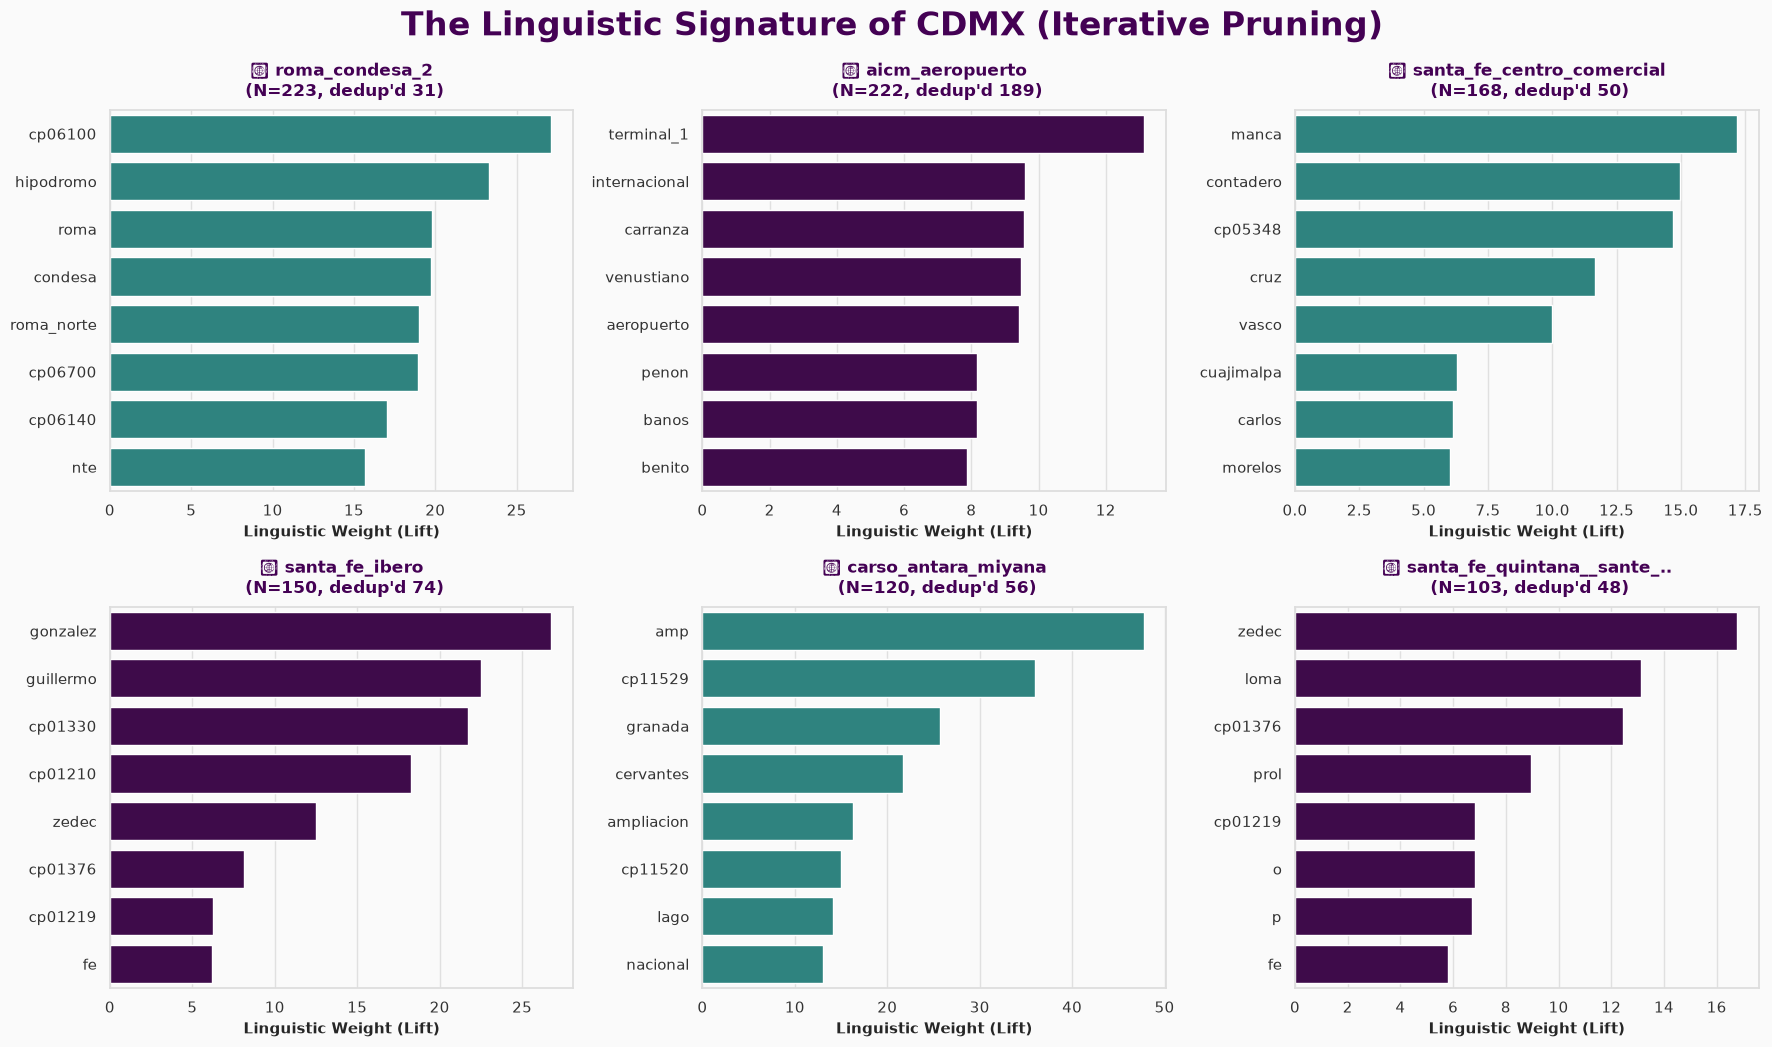

✅ Urban Lexicon visualizer successfully executed.


In [15]:
# ==============================================================================
# CELL 8 (FIXED): ITERATIVE "URBAN LEXICON" VISUALIZER
# ==============================================================================
# Purpose: Extract the "Linguistic Signature" of each zone.
# Enhancements:
#   1. Intra-Zone Address Deduplication (Removes uniform bar clusters)
#   2. Min Global Count Filter (Suppresses unique token noise)
#   3. Dynamic sizing for small vs large zones
# ==============================================================================
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🕵️‍♂️ Analyzing the DNA of Urban Vocabulary (Iterative Pruning Mode)...")

# --- 1. CONFIGURATION & PRUNING THRESHOLDS ---
TARGET_TOP_N_ZONES = 6
MIN_GLOBAL_WORD_COUNT = 3  # Word must appear at least 3 times globally

# Enforce the same canon from Cell 0
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'

# --- 2. GLOBAL PREPARATION (NOISE FILTERING) ---
# FIX: Using df_model and clean_address with a simple split
global_tokens = [t for addr in df_model['clean_address'] for t in str(addr).split()]
global_token_counts = Counter(global_tokens)
total_words_global = sum(global_token_counts.values())

# Identificamos el "Vocabulario Ruido" a nivel global (lo que no vale nada)
rare_global_words = {word for word, count in global_token_counts.items() if count < MIN_GLOBAL_WORD_COUNT}
print(f"✅ Noise-Pruning: Ignorando {len(rare_global_words)} palabras globales raras.")

# --- 3. AUDIT Y VISUALIZACIÓN ---
zone_lexicons = []

# Identificar las zonas de mayor volumen
# FIX: Using df_model
target_zones_counts = df_model['final_zone_name'].value_counts()
target_zones = target_zones_counts.nlargest(TARGET_TOP_N_ZONES).index.tolist()

# Crear el lienzo Opus
plt.figure(figsize=(18, 11), facecolor=OPUS_GREY)

for i, zone in enumerate(target_zones):
    plt.subplot(2, 3, i+1)

    # A. Intra-Zone Address Deduplication
    zone_addrs_df = df_model[df_model['final_zone_name'] == zone]

    initial_zone_len = len(zone_addrs_df)
    # FIX: Deduplicate based on the cleaned address
    unique_zone_addrs_df = zone_addrs_df.drop_duplicates(subset=['clean_address']).copy()
    num_addrs_deduplicated = initial_zone_len - len(unique_zone_addrs_df)

    # FIX: Tokenize using simple .split()
    zone_tokens = [t for addr in unique_zone_addrs_df['clean_address'] for t in str(addr).split()]

    # B. Apply Noise Pruning (remove globally rare words)
    zone_tokens_clean = [t for t in zone_tokens if t not in rare_global_words]

    zone_counts = Counter(zone_tokens_clean)
    num_zone_words = len(zone_tokens_clean)

    # If the zone is very small, force more distinction by picking fewer words
    top_N_most_common = 5 if num_zone_words < 100 else 8

    lift_data_for_zone = []

    # C. Calculate specificity ONLY for the clean, deduplicated intra-zone vocabulary
    for word, count in zone_counts.most_common(20):
        if count < 2: continue # Ignore tokens that only appear once inside a *clean* zone

        prob_zone = count / num_zone_words
        prob_global = global_token_counts[word] / total_words_global
        lift = prob_zone / prob_global

        lift_data_for_zone.append({
            'Zone': zone,
            'Word': word,
            'Count': count,
            'Specificity (Lift)': lift
        })

    # D. GRAFICAR (ENFORCED OPUS STYLE)
    df_lexicon_zone = pd.DataFrame(lift_data_for_zone)

    # Fallback safety check if the zone got completely pruned
    if df_lexicon_zone.empty:
        plt.title(f"📍 {zone}\n(Filtered out due to low variance)", fontsize=12, color=OPUS_PURPLE)
        continue

    top_words = df_lexicon_zone.nlargest(top_N_most_common, 'Specificity (Lift)').sort_values(by='Specificity (Lift)', ascending=False)

    bar_color = OPUS_TEAL if i % 2 == 0 else OPUS_PURPLE

    sns.barplot(
        data=top_words,
        x='Specificity (Lift)',
        y='Word',
        hue='Word',
        palette=[bar_color]*len(top_words),
        legend=False
    )

    # Limpieza estética del subplot
    short_name = (zone[:25] + '..') if len(zone) > 25 else zone
    subtitle = f"📍 {short_name}"
    subtitle_volume = f" (N={target_zones_counts[zone]}, dedup'd {num_addrs_deduplicated})"

    plt.title(f"{subtitle}\n{subtitle_volume}", fontsize=12, fontweight='bold', color=OPUS_PURPLE, pad=10)
    plt.xlabel("Linguistic Weight (Lift)", fontsize=11, fontweight='bold')
    plt.ylabel("")

# Título Principal
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("The Linguistic Signature of CDMX (Iterative Pruning)", fontsize=24, fontweight='bold', color=OPUS_PURPLE)
plt.show()

print("✅ Urban Lexicon visualizer successfully executed.")

In [17]:
'''# ==============================================================================
# CELL 14: THE GIANT ARRIVES - BETO (SOP CERO-ESPERAS EDITION) - FIXED
# ==============================================================================
import os
import logging
import torch
import torch.nn as nn
import copy
# EL FIX: AdamW ya no se importa de transformers, se usa el de torch.optim
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# --- 1. THE SILENCERS & AUTH ---
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
hf_logging.set_verbosity_error()

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    from huggingface_hub import login
    print("✅ Hugging Face Token detectado. Autenticando...")
    login(token=hf_token)
else:
    print("⚠️ HF_TOKEN no encontrado. Continuando en modo anónimo.")

print("\n⏳ Awakening BETO (Spanish BERT) via AutoAPI...")

# --- 2. TOKENIZADOR & PREPARACIÓN DE DATOS ---
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def bert_encode(addresses, max_len=64):
    input_ids, attention_masks = [], []
    for addr in addresses:
        encoded = tokenizer(
            str(addr), add_special_tokens=True, max_length=max_len,
            padding='max_length', return_attention_mask=True,
            truncation=True, return_tensors='pt'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

print("⏳ Tokenizing for BERT (X_train and X_val)...")
train_ids, train_masks = bert_encode(X_train)
val_ids, val_masks = bert_encode(X_val)

train_y = torch.tensor([zone_to_idx[y] for y in y_train])
val_y = torch.tensor([zone_to_idx[y] for y in y_val])

bert_train_loader = DataLoader(TensorDataset(train_ids, train_masks, train_y), batch_size=16, shuffle=True)
bert_val_loader = DataLoader(TensorDataset(val_ids, val_masks, val_y), batch_size=16)

# --- 3. BETO ARCHITECTURE ---
class BETOWithCustomHead(nn.Module):
    def __init__(self, model_name, num_classes, dropout_rate=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(768 * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()

        sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        avg_pool = sum_embeddings / sum_mask

        hidden_states_masked = hidden_states.masked_fill(input_mask_expanded == 0, -1e9)
        max_pool, _ = torch.max(hidden_states_masked, dim=1)

        fused_features = torch.cat((avg_pool, max_pool), dim=1)
        return self.classifier(self.dropout(fused_features))

# --- 4. SOP LOGIC (LOAD vs TRAIN) ---
model_bert = BETOWithCustomHead(model_name, num_classes=len(unique_zones)).to(device)
BETO_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_pienza_babel_beto_champion.pth")

if os.path.exists(BETO_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando Pesos Pesados (BETO) desde {BETO_PATH}...")
    model_bert.load_state_dict(torch.load(BETO_PATH, map_location=device))
    model_bert.eval()
    print("✅ miniBETO cargado exitosamente en CPU.")
else:
    print(f"🚀 Fine-tuning BETO on {device}...")
    optimizer = AdamW(model_bert.parameters(), lr=2e-5, eps=1e-8)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    EPOCHS_BETO, patience, best_val_f1 = 25, 5, 0
    best_model_wts = copy.deepcopy(model_bert.state_dict())
    no_improve_epochs = 0

    for epoch in range(EPOCHS_BETO):
        model_bert.train()
        for batch in bert_train_loader:
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            model_bert.zero_grad()
            logits = model_bert(b_input_ids, b_input_mask)
            loss = criterion(logits, b_labels)
            loss.backward()
            optimizer.step()

        model_bert.eval()
        all_preds = []
        with torch.no_grad():
            for batch in bert_val_loader:
                b_input_ids, b_input_mask, _ = [t.to(device) for t in batch]
                logits = model_bert(b_input_ids, b_input_mask)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())

        precision, recall, f1, _ = precision_recall_fscore_support(val_y.tolist(), all_preds, average='weighted', zero_division=0)
        print(f"Epoch {epoch+1:02d} | F1-Score (Val): {f1:.3f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            best_model_wts = copy.deepcopy(model_bert.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience: break

    model_bert.load_state_dict(best_model_wts)
    torch.save(model_bert.state_dict(), BETO_PATH)
    print(f"✅ Fine-tuning complete. Saved to {BETO_PATH}")

# --- 5. FINAL SCIENTIFIC EVALUATION ---
print("\n" + "="*80)
print("🔬 FINAL SCIENTIFIC EVALUATION REPORT (BETO)")
print("="*80)

model_bert.eval()
final_preds = []
with torch.no_grad():
    for batch in bert_val_loader:
        b_input_ids, b_input_mask, _ = [t.to(device) for t in batch]
        logits = model_bert(b_input_ids, b_input_mask)
        final_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())

target_names = [idx_to_zone[i] for i in range(len(unique_zones))]
print(classification_report(val_y.tolist(), final_preds, target_names=target_names, zero_division=0))
print("-" * 80)'''

'# ==============================================================================\n# CELL 14: THE GIANT ARRIVES - BETO (SOP CERO-ESPERAS EDITION) - FIXED\n# ==============================================================================\nimport os\nimport logging\nimport torch\nimport torch.nn as nn\nimport copy\n# EL FIX: AdamW ya no se importa de transformers, se usa el de torch.optim\nfrom transformers import AutoTokenizer, AutoModel, logging as hf_logging\nfrom torch.optim import AdamW\nfrom torch.utils.data import TensorDataset, DataLoader\nfrom sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report\n\n# --- 1. THE SILENCERS & AUTH ---\nos.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"\nos.environ["TOKENIZERS_PARALLELISM"] = "false"\nhf_logging.set_verbosity_error()\n\nhf_token = os.environ.get("HF_TOKEN")\nif hf_token:\n    from huggingface_hub import login\n    print("✅ Hugging Face Token detectado. Autenticando...")\n    login(token=hf_token

In [18]:
# ==============================================================================
# CELL 15: EXPORT HOLDOUT AUDIT PARQUET -> data/dumped_files/ (COLAB EDITION)
# ==============================================================================
import pandas as pd
import torch
import torch.nn.functional as F
import os

print("⏳ Rebuilding holdout audit with semantic zone names...")

# 🔴 FIX 1: En lugar de buscar un JSON local que no existe en Colab,
# generamos el mapa semántico directo del DataFrame original en memoria.
zone_to_semantic = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

# zone_to_idx from Cell 5: zone_id -> integer (e.g. "P_1" -> 11)
clean_to_raw = df_nav.set_index("clean_address")["dropoff_address"].to_dict() if "dropoff_address" in df_nav.columns else {}

model.eval()
records = []

with torch.no_grad():
    for clean_addr, true_zone in zip(X_val, y_val):
        raw_addr = clean_to_raw.get(str(clean_addr), str(clean_addr))

        tokens = str(clean_addr).split()
        indices = [token_to_idx.get(t, token_to_idx.get("<unk>", 1)) for t in tokens]
        indices = indices[:30] + [token_to_idx.get("<pad>", 0)] * max(0, 30 - len(indices))

        # 🔴 FIX 2: Mandamos el tensor a la GPU para que no choque con el modelo
        tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(tensor_in)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

        # 🔴 FIX 3: Mapeo de predicciones usando los diccionarios en RAM
        pred_zone_id = idx_to_zone.get(pred_idx.item(), "unknown")
        pred_zone_name = zone_to_semantic.get(pred_zone_id, pred_zone_id)

        real_zone_id = str(true_zone)
        real_zone_name = zone_to_semantic.get(real_zone_id, real_zone_id)

        records.append({
            "raw_address":    raw_addr,
            "clean_address":  str(clean_addr),
            "real_zone":      real_zone_id,
            "real_zone_name": real_zone_name,
            "predicted_zone": pred_zone_name,
            "confidence":     round(conf.item(), 4),
            "correct":        pred_zone_name == real_zone_name,
        })

df_audit = pd.DataFrame(records)
print(f"✅ Done. {len(df_audit)} records | Accuracy: {df_audit['correct'].mean():.2%}")
print(df_audit.head(3).to_string())

# DUMP_DIR ya apunta a tu Google Drive
OUT_PATH = os.path.join(DUMP_DIR, "260702_minibabel_holdout_audit.parquet")
df_audit.to_parquet(OUT_PATH, index=False)
print("📦 Saved ->", OUT_PATH)

⏳ Rebuilding holdout audit with semantic zone names...
✅ Done. 678 records | Accuracy: 85.25%
                                                                                                                 raw_address                                                                                           clean_address real_zone             real_zone_name                                predicted_zone  confidence  correct
0  Blvd. Miguel de Cervantes Saavedra 161, Granada, Miguel Hidalgo, 11520 Ciudad de México, CDMX, México - Polanco / Anzures       blvd miguel de cervantes saavedra_161 granada miguel hidalgo cp11520 ciudad de mexico cdmx mexico      P_35                      lagos                                         lagos      0.9913     True
1                Vasco de Quiroga 4973, La Ponderosa, Cuajimalpa de Morelos, 05370 Ciudad de México, CDMX, México - Santa Fe  vasco de quiroga_4973 la ponderosa cuajimalpa de morelos cp05370 ciudad de mexico cdmx mexico santa fe       P_1  

In [19]:
# ==============================================================================
# CELL 16: EXPORT ARTIFACTS FOR PRODUCTION (VOCAB & SEMANTIC MAP)
# ==============================================================================
import json
import os

print("⏳ Materializing production artifacts to Drive...")

# 1. Construir el mapa semántico directo (Index -> Human Readable Name)
# Esto mapea el entero que predice el modelo (0, 1, 2...) directo a "Aeropuerto AICM", etc.
zone_to_semantic = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

idx_to_semantic_name = {}
for idx, zone_id in idx_to_zone.items():
    semantic_name = zone_to_semantic.get(zone_id, zone_id)
    idx_to_semantic_name[str(idx)] = semantic_name

# Ruta de salida para el mapa semántico
semantic_path = os.path.join(DUMP_DIR, "idx_to_zone_to_semantics.json")
with open(semantic_path, 'w', encoding='utf-8') as f:
    json.dump(idx_to_semantic_name, f, ensure_ascii=False, indent=4)
print(f"✅ Semantic Mapping saved ({len(idx_to_semantic_name)} classes) -> {semantic_path}")

# 2. Guardar el token_to_idx (Vocabulario completo del Tokenizer)
# Crucial para que Streamlit convierta el texto crudo a los mismos números enteros
vocab_path = os.path.join(DUMP_DIR, "token_to_idx.json")
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump(token_to_idx, f, ensure_ascii=False, indent=4)
print(f"✅ Tokenizer Vocabulary saved ({len(token_to_idx)} tokens) -> {vocab_path}")

print("\n🎉 ALL COLAB ARTIFACTS ARE READY FOR EXPORT!")

⏳ Materializing production artifacts to Drive...
✅ Semantic Mapping saved (63 classes) -> /workspaces/pienza/data/dumped_files/idx_to_zone_to_semantics.json
✅ Tokenizer Vocabulary saved (2502 tokens) -> /workspaces/pienza/data/dumped_files/token_to_idx.json

🎉 ALL COLAB ARTIFACTS ARE READY FOR EXPORT!
